<a href="https://colab.research.google.com/github/danishasifahmed/p1-ml-pipeline/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# ML models we will train today
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Metrics to evaluate model quality
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# MLflow — the star of Day 4
import mlflow
import mlflow.sklearn   # sklearn-specific MLflow functions

# Dataset and preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

%matplotlib inline
sns.set_theme(style="whitegrid")
print("All imports successful ✓")
print(f"MLflow version: {mlflow.__version__}")


All imports successful ✓
MLflow version: 3.11.1


In [4]:
# Load raw data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# ── Day 2: Clean ──────────────────────────────────────────
def remove_outliers_iqr(dataframe, columns, multiplier=3.0):
    df_c = dataframe.copy()
    for col in columns:
        Q1 = df_c[col].quantile(0.25)
        Q3 = df_c[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c = df_c[(df_c[col] >= Q1 - multiplier*IQR) &
                    (df_c[col] <= Q3 + multiplier*IQR)]
    return df_c

df_clean = remove_outliers_iqr(df, ["AveRooms","AveBedrms","Population","AveOccup"])
df_clean = df_clean[df_clean["MedHouseVal"] < 5.0].copy()

# ── Day 3: Engineer features ──────────────────────────────
def engineer_features(dataframe):
    d = dataframe.copy()
    d["RoomsPerBedroom"]     = d["AveRooms"]  / (d["AveBedrms"] + 0.001)
    d["PopulationPerRoom"]   = d["Population"] / (d["AveRooms"]  + 0.001)
    d["IncomePerOccupant"]   = d["MedInc"]     / (d["AveOccup"]  + 0.001)
    d["IsNearCoast"]         = (d["Longitude"] < -119).astype(int)
    d["IsMajorMetro"]        = ((d["Latitude"] >= 33.5) &
                                (d["Latitude"] <= 38.5)).astype(int)
    d["IncomeAgeInteraction"]= d["MedInc"] * d["HouseAge"]
    return d

df_engineered = engineer_features(df_clean)

# ── Split ─────────────────────────────────────────────────
X = df_engineered.drop(columns=["MedHouseVal"])
y = df_engineered["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Preprocess ────────────────────────────────────────────
binary_features  = ["IsNearCoast", "IsMajorMetro"]
numeric_features = [c for c in X.columns if c not in binary_features]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough",    binary_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

final_columns     = numeric_features + binary_features
X_train_final     = pd.DataFrame(X_train_processed, columns=final_columns)
X_test_final      = pd.DataFrame(X_test_processed,  columns=final_columns)

# Save preprocessor for Day 6 (prediction)
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print(f"✓ Data ready")
print(f"  Train: {X_train_final.shape}  |  Test: {X_test_final.shape}")
print(f"  Features: {final_columns}")


✓ Data ready
  Train: (14752, 14)  |  Test: (3688, 14)
  Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerBedroom', 'PopulationPerRoom', 'IncomePerOccupant', 'IncomeAgeInteraction', 'IsNearCoast', 'IsMajorMetro']


In [5]:
def compute_metrics(model, X_train, X_test, y_train, y_test):
    """
    Train the model and compute 3 standard regression metrics.

    RMSE  — Root Mean Squared Error: average prediction error in the same
            units as the target ($100,000s). Lower is better.
    MAE   — Mean Absolute Error: average absolute difference. Less sensitive
            to large errors than RMSE. Lower is better.
    R²    — R-squared: what fraction of variance the model explains.
            1.0 = perfect, 0.0 = no better than predicting the mean.
    """
    # Train the model
    model.fit(X_train, y_train)

    # Predict on both sets — comparing these tells us if we're overfitting
    train_preds = model.predict(X_train)
    test_preds  = model.predict(X_test)

    metrics = {
        # Train metrics — how well the model learned the training data
        "train_rmse": np.sqrt(mean_squared_error(y_train, train_preds)),
        "train_mae":  mean_absolute_error(y_train, train_preds),
        "train_r2":   r2_score(y_train, train_preds),

        # Test metrics — how well it generalises to unseen data
        # These are the ones that actually matter for real-world performance
        "test_rmse":  np.sqrt(mean_squared_error(y_test, test_preds)),
        "test_mae":   mean_absolute_error(y_test, test_preds),
        "test_r2":    r2_score(y_test, test_preds),
    }
    return model, metrics, test_preds

print("Metrics helper defined ✓")

Metrics helper defined ✓


In [6]:
# Set the experiment name — all 3 model runs go into this one experiment
# If the experiment doesn't exist, MLflow creates it automatically
mlflow.set_experiment("california-housing-training")

# Verify it was created
experiment = mlflow.get_experiment_by_name("california-housing-training")
print(f"✓ Experiment created")
print(f"  Name:     {experiment.name}")
print(f"  Location: {experiment.artifact_location}")
print(f"\nAll model runs today will be logged under this experiment.")# Set the experiment name — all 3 model runs go into this one experiment
# If the experiment doesn't exist, MLflow creates it automatically
mlflow.set_experiment("california-housing-training")

# Verify it was created
experiment = mlflow.get_experiment_by_name("california-housing-training")
print(f"✓ Experiment created")
print(f"  Name:     {experiment.name}")
print(f"  Location: {experiment.artifact_location}")
print(f"\nAll model runs today will be logged under this experiment.")

2026/05/03 02:25:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 02:25:40 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 02:25:46 INFO mlflow.tracking.fluent: Experiment with name 'california-housing-training' does not exist. Creating a new experiment.


✓ Experiment created
  Name:     california-housing-training
  Location: /content/mlruns/1

All model runs today will be logged under this experiment.
✓ Experiment created
  Name:     california-housing-training
  Location: /content/mlruns/1

All model runs today will be logged under this experiment.


In [7]:
print("Training Model 1: Linear Regression...")

# Parameters for this model
lr_params = {
    "model_type": "LinearRegression",
    "fit_intercept": True,     # whether to include a constant term
    "normalize_data": True,    # reminder that we pre-scaled the data
    "random_state": 42
}

# --- MLflow run starts here ---
with mlflow.start_run(run_name="LinearRegression"):

    # 1. Create and train the model
    lr_model = LinearRegression(fit_intercept=True)
    lr_model, lr_metrics, lr_preds = compute_metrics(
        lr_model, X_train_final, X_test_final, y_train, y_test
    )

    # 2. Log parameters — what settings did we use?
    # log_param is for settings/hyperparameters (strings, ints, booleans)
    for param_name, param_value in lr_params.items():
        mlflow.log_param(param_name, param_value)

    # 3. Log metrics — how did the model perform?
    # log_metric is for numeric scores
    for metric_name, metric_value in lr_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # 4. Log the trained model itself as an artifact
    # This saves the model file so you can reload it later
    mlflow.sklearn.log_model(lr_model, "linear_regression_model")

    # 5. Save run ID so we can reference it later
    lr_run_id = mlflow.active_run().info.run_id

print(f"\n✓ Linear Regression logged to MLflow")
print(f"  Run ID:   {lr_run_id}")
print(f"  Test RMSE: {lr_metrics['test_rmse']:.4f}")
print(f"  Test MAE:  {lr_metrics['test_mae']:.4f}")
print(f"  Test R²:   {lr_metrics['test_r2']:.4f}")

Training Model 1: Linear Regression...


2026/05/03 02:25:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:25:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✓ Linear Regression logged to MLflow
  Run ID:   14d20a3a14f34bd5be6a34686a9f159e
  Test RMSE: 0.5577
  Test MAE:  0.4160
  Test R²:   0.6736


In [8]:
print("Training Model 2: Ridge Regression...")

ridge_params = {
    "model_type": "Ridge",
    "alpha": 1.0,          # regularization strength — we'll tune this in Day 5
    "fit_intercept": True,
    "random_state": 42
}

with mlflow.start_run(run_name="Ridge"):

    ridge_model = Ridge(alpha=ridge_params["alpha"],
                        fit_intercept=ridge_params["fit_intercept"])
    ridge_model, ridge_metrics, ridge_preds = compute_metrics(
        ridge_model, X_train_final, X_test_final, y_train, y_test
    )

    for param_name, param_value in ridge_params.items():
        mlflow.log_param(param_name, param_value)

    for metric_name, metric_value in ridge_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.sklearn.log_model(ridge_model, "ridge_model")

    ridge_run_id = mlflow.active_run().info.run_id

print(f"\n✓ Ridge Regression logged to MLflow")
print(f"  Run ID:    {ridge_run_id}")
print(f"  Test RMSE: {ridge_metrics['test_rmse']:.4f}")
print(f"  Test MAE:  {ridge_metrics['test_mae']:.4f}")
print(f"  Test R²:   {ridge_metrics['test_r2']:.4f}")

Training Model 2: Ridge Regression...


2026/05/03 02:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:26:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✓ Ridge Regression logged to MLflow
  Run ID:    19ffa2bc2d784195a82bbc388f9a3d42
  Test RMSE: 0.5577
  Test MAE:  0.4160
  Test R²:   0.6736


In [9]:
print("Training Model 3: Random Forest (this takes ~1–2 minutes)...")

rf_params = {
    "model_type":      "RandomForest",
    "n_estimators":    100,    # number of trees — more = better but slower
    "max_depth":       15,     # max depth of each tree — limits overfitting
    "min_samples_split": 5,    # min samples needed to split a node
    "min_samples_leaf":  2,    # min samples in a leaf node
    "random_state":    42      # reproducibility
}

with mlflow.start_run(run_name="RandomForest"):

    rf_model = RandomForestRegressor(
        n_estimators     = rf_params["n_estimators"],
        max_depth        = rf_params["max_depth"],
        min_samples_split= rf_params["min_samples_split"],
        min_samples_leaf = rf_params["min_samples_leaf"],
        random_state     = rf_params["random_state"],
        n_jobs           = -1   # use all CPU cores — not logged, just a speed setting
    )

    rf_model, rf_metrics, rf_preds = compute_metrics(
        rf_model, X_train_final, X_test_final, y_train, y_test
    )

    for param_name, param_value in rf_params.items():
        mlflow.log_param(param_name, param_value)

    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    # Log feature importances as a CSV artifact
    # Feature importance tells you which features the forest relied on most
    importance_df = pd.DataFrame({
        "feature":   X_train_final.columns,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df.to_csv("feature_importances.csv", index=False)
    mlflow.log_artifact("feature_importances.csv")  # saves the file to MLflow

    mlflow.sklearn.log_model(rf_model, "random_forest_model")

    rf_run_id = mlflow.active_run().info.run_id

print(f"\n✓ Random Forest logged to MLflow")
print(f"  Run ID:    {rf_run_id}")
print(f"  Test RMSE: {rf_metrics['test_rmse']:.4f}")
print(f"  Test MAE:  {rf_metrics['test_mae']:.4f}")
print(f"  Test R²:   {rf_metrics['test_r2']:.4f}")

Training Model 3: Random Forest (this takes ~1–2 minutes)...


2026/05/03 02:26:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:26:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✓ Random Forest logged to MLflow
  Run ID:    0136a94e792a44aeb0fdd6123ffcd522
  Test RMSE: 0.4391
  Test MAE:  0.2905
  Test R²:   0.7977


In [10]:
# Build a clean comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge", "RandomForest"],
    "Test RMSE": [
        lr_metrics["test_rmse"],
        ridge_metrics["test_rmse"],
        rf_metrics["test_rmse"]
    ],
    "Test MAE": [
        lr_metrics["test_mae"],
        ridge_metrics["test_mae"],
        rf_metrics["test_mae"]
    ],
    "Test R²": [
        lr_metrics["test_r2"],
        ridge_metrics["test_r2"],
        rf_metrics["test_r2"]
    ],
    "Train R²": [
        lr_metrics["train_r2"],
        ridge_metrics["train_r2"],
        rf_metrics["train_r2"]
    ]
})

comparison = comparison.round(4)
print("=== Model Comparison ===")
display(comparison)

# Highlight the winner
best_model_name = comparison.loc[comparison["Test R²"].idxmax(), "Model"]
best_r2         = comparison["Test R²"].max()
print(f"\n🏆 Best model: {best_model_name} with Test R² = {best_r2:.4f}")

=== Model Comparison ===


,Model,Test RMSE,Test MAE,Test R²,Train R²
0,LinearRegression,0.5577,0.4160,0.6736,0.6591
1,Ridge,0.5577,0.4160,0.6736,0.6591
2,RandomForest,0.4391,0.2905,0.7977,0.9345



🏆 Best model: RandomForest with Test R² = 0.7977


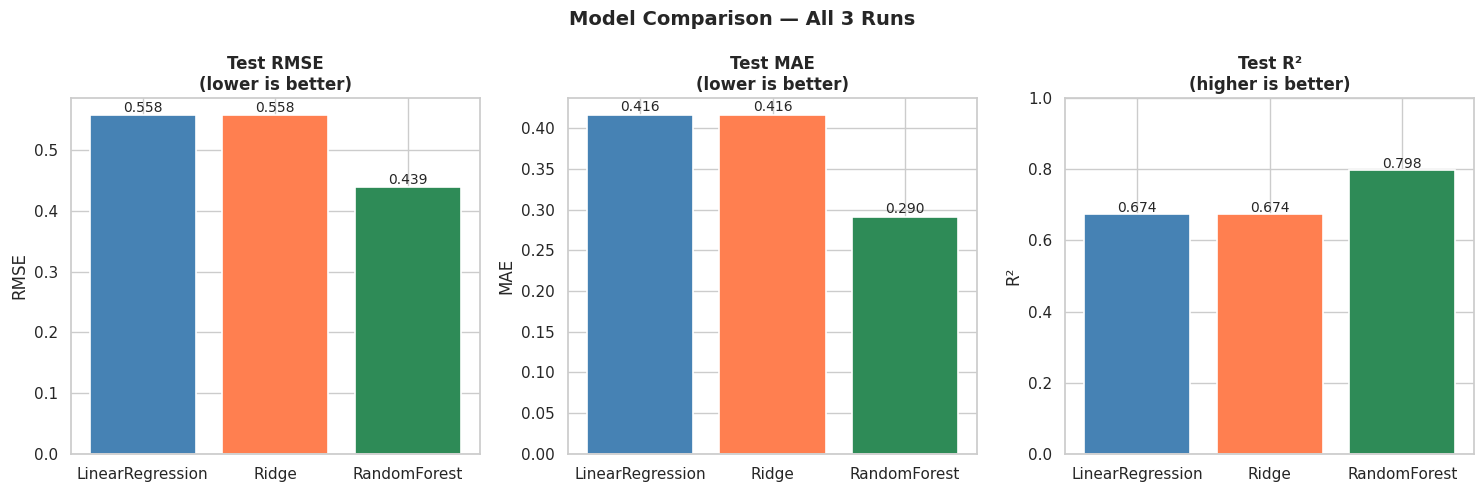

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models     = ["LinearRegression", "Ridge", "RandomForest"]
colors     = ["steelblue", "coral", "seagreen"]

# Plot 1: Test RMSE (lower is better)
rmse_vals = [lr_metrics["test_rmse"], ridge_metrics["test_rmse"], rf_metrics["test_rmse"]]
axes[0].bar(models, rmse_vals, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Test RMSE\n(lower is better)", fontweight="bold")
axes[0].set_ylabel("RMSE")
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

# Plot 2: Test MAE (lower is better)
mae_vals = [lr_metrics["test_mae"], ridge_metrics["test_mae"], rf_metrics["test_mae"]]
axes[1].bar(models, mae_vals, color=colors, edgecolor="white", linewidth=1.2)
axes[1].set_title("Test MAE\n(lower is better)", fontweight="bold")
axes[1].set_ylabel("MAE")
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

# Plot 3: Test R² (higher is better)
r2_vals = [lr_metrics["test_r2"], ridge_metrics["test_r2"], rf_metrics["test_r2"]]
axes[2].bar(models, r2_vals, color=colors, edgecolor="white", linewidth=1.2)
axes[2].set_title("Test R²\n(higher is better)", fontweight="bold")
axes[2].set_ylabel("R²")
axes[2].set_ylim(0, 1.0)
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Model Comparison — All 3 Runs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

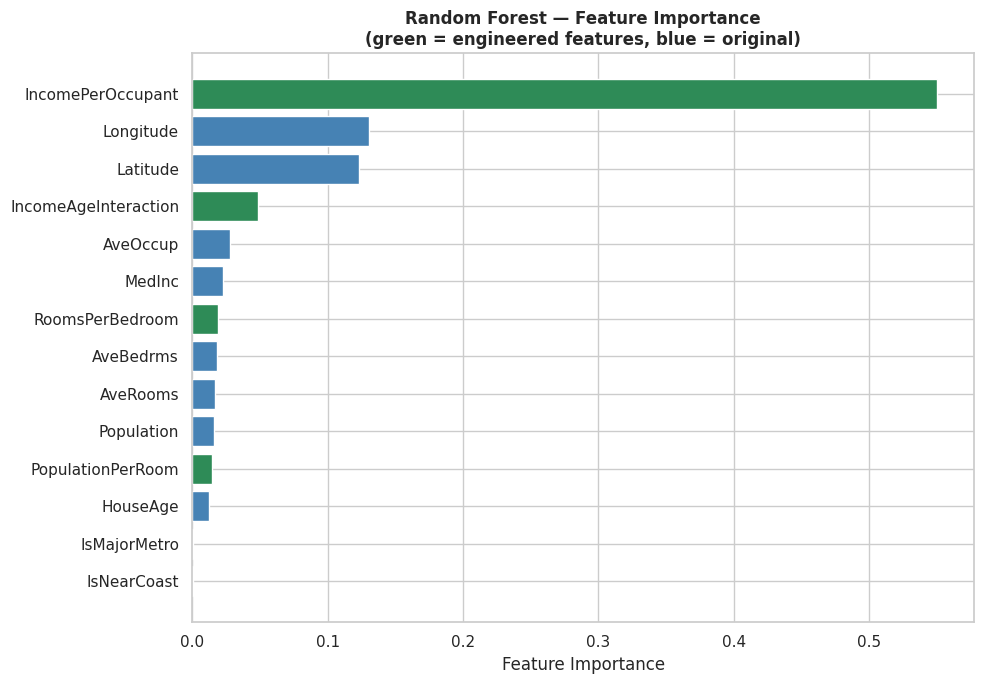


Top 5 most important features:
  ★ engineered  IncomePerOccupant             : 0.5500
    original  Longitude                     : 0.1308
    original  Latitude                      : 0.1235
  ★ engineered  IncomeAgeInteraction          : 0.0488
    original  AveOccup                      : 0.0277


In [12]:
# Feature importance shows which features the Random Forest relied on most
# This is a powerful tool for explaining your model to business stakeholders

importance_df = pd.DataFrame({
    "feature":    X_train_final.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=True)  # ascending for horizontal bar chart

plt.figure(figsize=(10, 7))
colors_imp = ["steelblue" if f not in
              ["RoomsPerBedroom","PopulationPerRoom","IncomePerOccupant",
               "IsNearCoast","IsMajorMetro","IncomeAgeInteraction"]
              else "seagreen" for f in importance_df["feature"]]

plt.barh(importance_df["feature"], importance_df["importance"],
         color=colors_imp, edgecolor="white")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Feature Importance\n(green = engineered features, blue = original)",
          fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
top5 = importance_df.sort_values("importance", ascending=False).head(5)
for _, row in top5.iterrows():
    tag = "★ engineered" if row["feature"] in \
          ["RoomsPerBedroom","PopulationPerRoom","IncomePerOccupant",
           "IsNearCoast","IsMajorMetro","IncomeAgeInteraction"] else "  original"
    print(f"  {tag}  {row['feature']:30s}: {row['importance']:.4f}")

In [13]:
# Identify and save the best model based on Test R²
best_idx   = np.argmax([lr_metrics["test_r2"],
                         ridge_metrics["test_r2"],
                         rf_metrics["test_r2"]])

model_map  = {
    0: (lr_model,    "LinearRegression", lr_metrics,    lr_run_id),
    1: (ridge_model, "Ridge",            ridge_metrics, ridge_run_id),
    2: (rf_model,    "RandomForest",     rf_metrics,    rf_run_id)
}

best_model, best_name, best_metrics, best_run = model_map[best_idx]

# Save the best model as a pickle file
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save metadata about the best model — useful in Day 5 and Day 6
best_model_info = {
    "model_name":  best_name,
    "run_id":      best_run,
    "test_rmse":   best_metrics["test_rmse"],
    "test_mae":    best_metrics["test_mae"],
    "test_r2":     best_metrics["test_r2"],
    "features":    final_columns
}

with open("best_model_info.pkl", "wb") as f:
    pickle.dump(best_model_info, f)

print(f"✓ Best model saved: {best_name}")
print(f"  Test R²:   {best_metrics['test_r2']:.4f}")
print(f"  Test RMSE: {best_metrics['test_rmse']:.4f}")
print(f"  Test MAE:  {best_metrics['test_mae']:.4f}")
print(f"  MLflow Run ID: {best_run}")

✓ Best model saved: RandomForest
  Test R²:   0.7977
  Test RMSE: 0.4391
  Test MAE:  0.2905
  MLflow Run ID: 0136a94e792a44aeb0fdd6123ffcd522


In [14]:
# Pull all runs from MLflow and display them in a clean table
# In a real team, you'd view this in the MLflow web UI (mlflow ui command)
runs_df = mlflow.search_runs(
    experiment_names=["california-housing-training"],
    order_by=["metrics.test_r2 DESC"]  # best R² first
)

# Select only the columns we care about
display_cols = [
    "tags.mlflow.runName",
    "metrics.test_r2",
    "metrics.test_rmse",
    "metrics.test_mae",
    "metrics.train_r2",
    "params.model_type"
]

print("=== MLflow Experiment Runs ===")
display(runs_df[display_cols].round(4))
print(f"\nTotal runs logged: {len(runs_df)}")
print(f"Best run: {runs_df.iloc[0]['tags.mlflow.runName']} "
      f"(R² = {runs_df.iloc[0]['metrics.test_r2']:.4f})")

=== MLflow Experiment Runs ===


,tags.mlflow.runName,metrics.test_r2,metrics.test_rmse,metrics.test_mae,metrics.train_r2,params.model_type
0,RandomForest,0.7977,0.4391,0.2905,0.9345,RandomForest
1,LinearRegression,0.6736,0.5577,0.4160,0.6591,LinearRegression
2,Ridge,0.6736,0.5577,0.4160,0.6591,Ridge



Total runs logged: 3
Best run: RandomForest (R² = 0.7977)


In [15]:
print("=" * 55)
print("TRAINING SUMMARY — Ready for Day 5")
print("=" * 55)
print(f"""
MODELS TRAINED & LOGGED TO MLFLOW:
  1. LinearRegression  — Test R²: {lr_metrics['test_r2']:.4f}
  2. Ridge             — Test R²: {ridge_metrics['test_r2']:.4f}
  3. RandomForest      — Test R²: {rf_metrics['test_r2']:.4f}

BEST MODEL: {best_name}
  Test R²:   {best_metrics['test_r2']:.4f}
  Test RMSE: {best_metrics['test_rmse']:.4f}
  Test MAE:  {best_metrics['test_mae']:.4f}

MLFLOW EXPERIMENT: california-housing-training
  All 3 runs recorded with params, metrics, and model files

FILES SAVED:
  ✓ best_model.pkl
  ✓ best_model_info.pkl
  ✓ preprocessor.pkl
  ✓ feature_importances.csv

READY FOR DAY 5:
  → evaluate.py — deep dive on the best model
  → Residual analysis, error distribution
  → Log final evaluation artifacts to MLflow
""")

TRAINING SUMMARY — Ready for Day 5

MODELS TRAINED & LOGGED TO MLFLOW:
  1. LinearRegression  — Test R²: 0.6736
  2. Ridge             — Test R²: 0.6736
  3. RandomForest      — Test R²: 0.7977

BEST MODEL: RandomForest
  Test R²:   0.7977
  Test RMSE: 0.4391
  Test MAE:  0.2905

MLFLOW EXPERIMENT: california-housing-training
  All 3 runs recorded with params, metrics, and model files

FILES SAVED:
  ✓ best_model.pkl
  ✓ best_model_info.pkl
  ✓ preprocessor.pkl
  ✓ feature_importances.csv

READY FOR DAY 5:
  → evaluate.py — deep dive on the best model
  → Residual analysis, error distribution
  → Log final evaluation artifacts to MLflow

